In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import sklearn as sk
import polars as pl
import matplotlib.pyplot as plt
import os
import shutil
from IPython.display import display

# Pre-process Dataset

In [2]:
# Manually download dataset into /docs
# Check files/ File path
DOCS_PATH = "/content/docs"

print("Files in docs folder:", os.listdir(DOCS_PATH))

TRAIN_PATH = os.path.join(DOCS_PATH, "train.parquet")
TEST_PATH = os.path.join(DOCS_PATH, "test.parquet")

# Lazy load
train_df = pl.scan_parquet(TRAIN_PATH)
test_df = pl.scan_parquet(TEST_PATH)

# Print schema
print("Schema:")
print(test_df.schema)

# Get shape (forces minimal computation)
print("Train shape:", train_df.select(pl.count()).collect())
print("Test shape:", test_df.select(pl.count()).collect())
# Preview data (only loads small sample)
display(train_df.head(5).collect())
display(test_df.head(5).collect())

Files in docs folder: ['train.parquet', 'test.parquet']
Schema:
Schema({'id': String, 'code': String, 'sub_code': String, 'sub_category': String, 'horizon': Int32, 'ts_index': Int32, 'feature_a': Int32, 'feature_b': Float64, 'feature_c': Float64, 'feature_d': Float64, 'feature_e': Float64, 'feature_f': Float64, 'feature_g': Float64, 'feature_h': Float64, 'feature_i': Float64, 'feature_j': Float64, 'feature_k': Float64, 'feature_l': Float64, 'feature_m': Float64, 'feature_n': Float64, 'feature_o': Float64, 'feature_p': Float64, 'feature_q': Float64, 'feature_r': Float64, 'feature_s': Float64, 'feature_t': Float64, 'feature_u': Float64, 'feature_v': Float64, 'feature_w': Float64, 'feature_x': Float64, 'feature_y': Float64, 'feature_z': Float64, 'feature_aa': Float64, 'feature_ab': Float64, 'feature_ac': Float64, 'feature_ad': Float64, 'feature_ae': Float64, 'feature_af': Float64, 'feature_ag': Float64, 'feature_ah': Float64, 'feature_ai': Float64, 'feature_aj': Float64, 'feature_ak': Flo

/tmp/ipykernel_175077/1005924137.py:16: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(test_df.schema)
/tmp/ipykernel_175077/1005924137.py:19: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  print("Train shape:", train_df.select(pl.count()).collect())


Train shape: shape: (1, 1)
┌─────────┐
│ count   │
│ ---     │
│ u32     │
╞═════════╡
│ 5337414 │
└─────────┘
Test shape: shape: (1, 1)
┌─────────┐
│ count   │
│ ---     │
│ u32     │
╞═════════╡
│ 1447107 │
└─────────┘


/tmp/ipykernel_175077/1005924137.py:20: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  print("Test shape:", test_df.select(pl.count()).collect())


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,89,29,16.364093,7.464023,5.966933,1.622184,10.26136,4.914369,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",1,89,53,2.858806,5.050617,15.906651,10.879453,3.072151,4.091032,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",3,89,51,9.585452,1.076268,9.004147,16.74049,15.166901,11.427983,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.362894,115.953552
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",10,89,44,8.840588,15.034634,4.17078,1.584433,5.383462,3.099428,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.667023,64.573073
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,90,28,2.303825,7

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",3,3647,95,10.365266,3.209321,8.109339,9.043471,10.123041,15.722121,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",10,3647,88,2.571477,15.234848,16.505699,0.230426,10.145378,10.159641,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",25,3647,71,5.524709,6.931663,8.939537,0.668187,16.578701,3.15069,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",1,3647,97,10.293758,14.89366,9.435544,2.335377,3.477961,15.680595,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…",

In [3]:
train_df = (
    pl.scan_parquet(TRAIN_PATH)
    .sort(["code", "sub_code", "sub_category", "ts_index"])
)
# Collect with streaming (key part)
train_df = train_df.collect(streaming=True)

/tmp/ipykernel_175077/3781260164.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  train_df = train_df.collect(streaming=True)


In [4]:
num_cols = [col for col in train_df.columns if col not in ["code", "ts_index"]]

# Forward fill
train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(strategy="forward")
    .over("code")
    .alias(col)
    for col in num_cols
])

# Median imputation
train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(pl.col(col).median().over("code"))
    .alias(col)
    for col in num_cols
])

Summary Statistics

In [5]:
print(train_df.describe())

shape: (9, 95)
┌────────────┬───────────┬──────────┬──────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ id        ┆ code     ┆ sub_code ┆ … ┆ feature_c ┆ feature_c ┆ y_target  ┆ weight    │
│ ---        ┆ ---       ┆ ---      ┆ ---      ┆   ┆ g         ┆ h         ┆ ---       ┆ ---       │
│ str        ┆ str       ┆ str      ┆ str      ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64       │
│            ┆           ┆          ┆          ┆   ┆ f64       ┆ f64       ┆           ┆           │
╞════════════╪═══════════╪══════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 5337414   ┆ 5337414  ┆ 5337414  ┆ … ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e │
│            ┆           ┆          ┆          ┆   ┆ 6         ┆ 6         ┆ 6         ┆ 6         │
│ null_count ┆ 0         ┆ 0        ┆ 0        ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ mean       ┆ null      ┆ null     ┆ null     ┆ … ┆ 1.061604  ┆ 2.323426  ┆

Feature Distributions

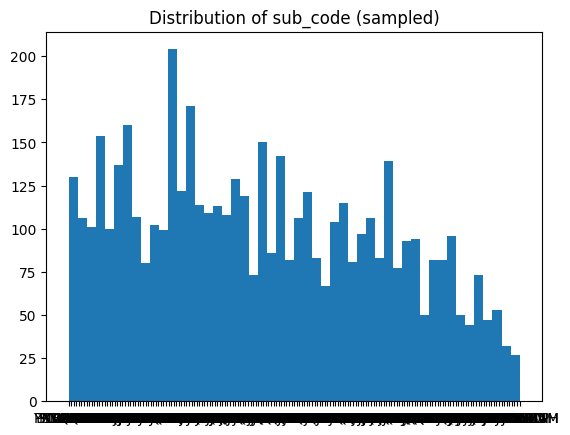

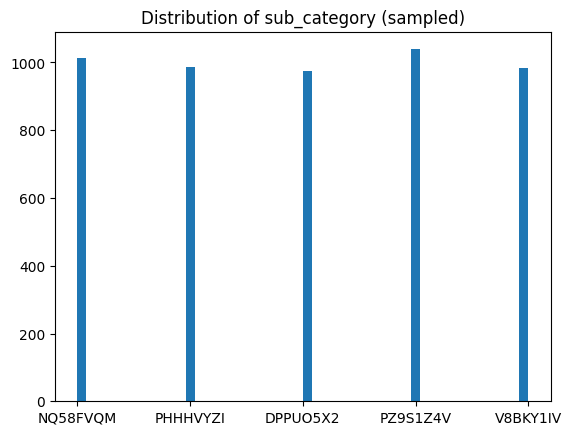

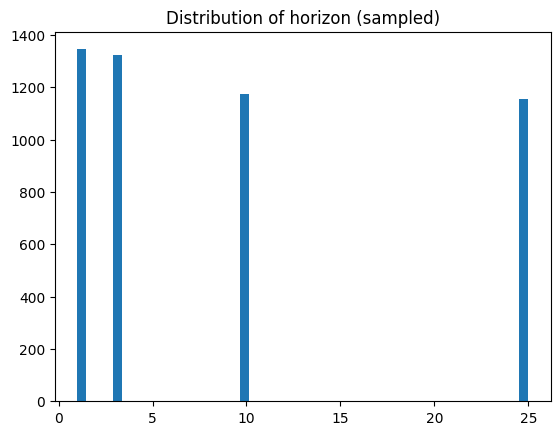

In [6]:
sample_df = train_df.select(num_cols[1:4]).sample(5000)

for col in num_cols[1:4]:
    values = sample_df[col].to_numpy()

    plt.figure()
    plt.hist(values, bins=50)
    plt.title(f"Distribution of {col} (sampled)")
    plt.show()

Volatility Check

In [7]:
# Rolling Volatility
train_df = train_df.with_columns([
    pl.col("y_target")
    .rolling_std(window_size=10)
    .over("code")
    .alias("y_volatility")
])

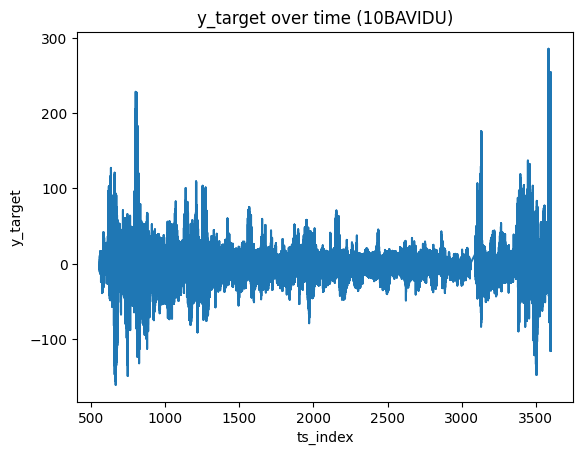

In [8]:
sample_code = train_df.select("code").unique().to_series()[0]

sample_df = (
    train_df
    .filter(pl.col("code") == sample_code)
    .sort("ts_index")
)

plt.figure()
plt.plot(sample_df["ts_index"], sample_df["y_target"])
plt.title(f"y_target over time ({sample_code})")
plt.xlabel("ts_index")
plt.ylabel("y_target")
plt.show()


In [9]:
train_df = train_df.with_columns([
    pl.col("y_target")
    .rolling_mean(window_size=10)
    .over("code")
    .alias("y_rolling_mean")
])
train_df.sample(10)

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight,y_volatility,y_rolling_mean
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""1HEMHZK2__GTE8D37W__NQ58FVQM__…","""1HEMHZK2""","""GTE8D37W""","""NQ58FVQM""",10.0,1438,22.0,10.298637,8.944556,2.685397,10.977181,0.524983,7.368902,0.0003,0.003994,0.000231,0.005919,0.038345,2.010323,0.046523,0.002882,0.000187,0.001027,0.001246,0.00026,0.002892,0.004694,0.030125,-1.21479,0.14459,-14.935354,-1.806984,0.006388,1.992517,3.706149,3.100566,0.017954,…,44368.217242,92961.687621,280031.166714,468710.142161,14685.123775,0.000202,27695.315967,9.635293,10555.349881,356.368128,41.794918,0.072231,1.35812,0.059181,2.339186,3.434054,2.636627,-0.279087,-1.474135,-3.64989,3.300422,0.245987,0.223844,-0.000644,-0.000144,-0.000889,-0.000068,-0.001807,-0.000079,0.005498,0.769113,0.019396,0.0,0.002765,1.3200e7,0.003695,0.002603
"""W2MW3G2L__DYJUJX3J__V8BKY1IV__…","""W2MW3G2L""","""DYJUJX3J""","""V8BKY1IV""",3.0,2318,24.0,14.630134,6.633399,12.412449,0.601995,1.037186,12.498726,0.000261,0.011302,0.001165,0.000051,0.51614,1.552899,-0.118092,0.001236,0.000815,0.001577,0.07744,4.204035,0.035674,0.098051,0.055078,-8.496873,0.220663,-1.347952,14.904657,0.010678,0.051274,0.005601,0.008321,0.0024,…,34298.264,670.940586,2.4541e6,1.2634e6,48527.368825,0.048814,218226.066821,0.268963,10132.811197,282293.838928,0.066648,0.642085,14.175879,0.339629,0.351448,0.395762,0.148175,-0.486888,-0.19498,-4.064245,0.097103,3.18295,4.398234,-0.000489,-0.020649,-0.000618,-0.034361,-0.001775,-0.001108,0.007135,1.274793,0.047943,0.0,-0.077982,4440.030773,0.051193,-0.022362
"""660DZME0__NSYBU89B__V8BKY1IV__…","""660DZME0""","""NSYBU89B""","""V8BKY1IV""",1.0,3041,69.0,3.666457,12.347593,7.487832,8.633196,0.46976,0.991553,0.000337,0.000335,0.000229,0.000162,0.337327,0.123312,0.365212,0.0,0.027665,0.072093,3.190901,1.202186,1.004829,1.059849,54.078583,-25.062883,30.059374,155.986059,-21.199314,0.0,0.252845,0.391662,0.84078,1.963773,…,779.087428,0.700525,302907.519164,167983.14813,171170.313146,0.008109,546811.090235,1.409222,964.878042,3553.836768,0.001351,473.995768,824.551314,780.975765,0.193184,0.007966,0.003215,-0.500003,-3.124528,-2.801154,0.092043,0.258248,0.453521,-0.036742,-0.012359,-0.021145,-0.897964,-0.032427,-0.527469,-0.051649,0.092839,0.0618,2.0,0.150863,225.474697,0.14179,0.162915
"""HYOGKLEV__NSYBU89B__PHHHVYZI__…","""HYOGKLEV""","""NSYBU89B""","""PHHHVYZI""",3.0,3092,25.0,12.077518,9.252748,4.655952,7.802059,10.88874,12.223854,0.000422,0.014692,0.000045,0.000177,0.741136,0.145942,0.065416,0.0,0.041031,0.028958,0.001673,0.020506,0.02267,0.465702,0.309741,14.854218,45.995597,-12.060308,0.681726,0.0,0.005745,0.016577,0.028413,0.006239,…,1599.271344,191.033375,17455.783173,6826.889515,18731.441836,0.148835,61913.937789,9.107437,15694.337173,297.563824,0.019331,0.352815,6.532001,0.160323,6.964617,0.476772,12.281152,-11.911064,-0.11267,-0.800045,0.075945,5.563402,11.291079,-0.001112,-0.024159,-0.000451,-0.000496,-0.001545,-0.001558,0.001005,2.073248,0.117739,0.0,-0.079147,2388.366131,0.105422,-0.1237

In [10]:
# Feature Importance Correlation
corr_df = train_df.select(
    [pl.corr(col, "y_target").alias(col) for col in num_cols[:10]]
)

print(corr_df)

shape: (1, 10)
┌─────┬──────────┬──────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ id  ┆ sub_code ┆ sub_category ┆ horizon   ┆ … ┆ feature_c ┆ feature_d ┆ feature_e ┆ feature_f │
│ --- ┆ ---      ┆ ---          ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ f64 ┆ f64      ┆ f64          ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═════╪══════════╪══════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ NaN ┆ NaN      ┆ NaN          ┆ -0.018719 ┆ … ┆ 0.00057   ┆ 0.000097  ┆ -0.000574 ┆ -0.000027 │
└─────┴──────────┴──────────────┴───────────┴───┴───────────┴───────────┴───────────┴───────────┘


# Baseline Model

First, the necessary libraries and modules are imported for the creation of this base model, which includes using HistGradientBoostingRegressor.

In [11]:
import numpy as np
import pandas as pd
import gc

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

import warnings
warnings.filterwarnings("ignore")

SEED = 42

print(train_df.shape)
train_df.head()

(5337414, 96)


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight,y_volatility,y_rolling_mean
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",3.0,3531,141.0,3.475385,15.13462,3.265031,10.380979,8.83843,2.01938,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,0.670754,0.017167,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",10.0,3531,134.0,12.707232,11.597299,6.034944,13.931955,9.418021,16.584339,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,5.601772,0.010329,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",25.0,3531,119.0,11.262484,1.45387,6.210146,8.292425,1.175443,15.234003,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,8.425576,0.016712,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",1.0,3531,143.0,2.296699,1.939771,15.459024,8.540194,16.673829,14.100175,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,-2.795824,0.032189,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",1.0,3532,142.0,4.631196,2.84

Next, we define features and target.

In [12]:
TARGET = "horizon"
TS_INDEX = "ts_index"
ID = "id"
CODE = "code"
SUBCODE = "sub_code"
SUBCATEGORY = "sub_category"

SAMPLE_FRAC = 0.01

train_df = (
    train_df
    .sample(fraction=SAMPLE_FRAC, seed=SEED)
    .sort(TS_INDEX)
)

FEATURES = [c for c in train_df.columns if c not in [TARGET, TS_INDEX, ID, CODE, SUBCODE, SUBCATEGORY]]
FEATURES = FEATURES[:50]

X = train_df.select(FEATURES)
y = train_df.select(TARGET)

Time-series validation splits are then defined to prevent data leakage.

---



In [13]:
N_SPLITS = 5

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

splits = list(tscv.split(X))

print(f"Number of splits: {len(splits)}")

Number of splits: 5


Furthermore, we determine weighted error metric using a flexible weighted RMSE implementation.

In [14]:
def weighted_rmse(y_true, y_pred, weights=None):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    if weights is None:
        weights = np.ones_like(y_true)

    weights = np.array(weights)

    mse = np.average((y_true - y_pred) ** 2, weights=weights)
    return np.sqrt(mse)

def compute_weights(df):

    return np.ones(len(df))

Most importantly, we train the baseline model. We are using the tree based model, HistGradientBoostingRegressor.

In [15]:
def train_baseline_hgbr(X, y, splits):

    fold_scores = []
    oof_predictions = np.zeros(len(X))

    X_np = X.to_numpy()
    y_np = y.to_numpy()

    for fold, (train_idx, val_idx) in enumerate(splits):

        print(f"\n===== Fold {fold+1} =====")

        X_train = X_np[train_idx]
        X_val   = X_np[val_idx]
        y_train = y_np[train_idx]
        y_val   = y_np[val_idx].flatten()

        model = HistGradientBoostingRegressor(
            max_iter=100,
            learning_rate=0.1,
            max_depth=6,
            min_samples_leaf=20,
            random_state=SEED
        )

        model.fit(X_train, y_train)

        preds = model.predict(X_val)
        oof_predictions[val_idx] = preds

        score = weighted_rmse(y_val, preds)
        fold_scores.append(score)

        print(f"Fold RMSE: {score:.5f}")

        del model, X_train, X_val
        gc.collect()

    return oof_predictions, fold_scores

Here we obtain the 'error magnitude' or RMSE of each split. This shows how well the base model learns.

In [16]:
oof_preds, fold_scores = train_baseline_hgbr(X,y,splits)
print("\n======================")
print("Baseline Results")
print("======================")
print("Fold Scores:", fold_scores)
print("Mean Score:", np.mean(fold_scores))


===== Fold 1 =====
Fold RMSE: 8.28822

===== Fold 2 =====
Fold RMSE: 8.30348

===== Fold 3 =====
Fold RMSE: 8.04543

===== Fold 4 =====
Fold RMSE: 8.06589

===== Fold 5 =====
Fold RMSE: 7.98388

Baseline Results
Fold Scores: [np.float64(8.288224783417238), np.float64(8.303478455817404), np.float64(8.04542653752729), np.float64(8.065890421736597), np.float64(7.983875096980536)]
Mean Score: 8.137379059095812


Next, we evaluate the model using competition metric.
We shall perform the same operations on test_df as done on train_df. The first step is to preprocess the test data.

In [17]:
test_df_processed = (
    pl.scan_parquet(TEST_PATH)
    .sort([CODE, SUBCODE, SUBCATEGORY, TS_INDEX])
    .collect(streaming=True)
)

exclude_cols_for_num_processing = [ID, CODE, SUBCODE, SUBCATEGORY, TS_INDEX, TARGET]

test_feature_cols = [
    col for col in test_df_processed.columns
    if col not in exclude_cols_for_num_processing and test_df_processed[col].dtype.is_numeric()
]

#Forward fill
test_df_processed = test_df_processed.with_columns([
    pl.col(col)
    .fill_null(strategy="forward")
    .over(CODE)
    .alias(col)
    for col in test_feature_cols
])

#Median imputation
test_df_processed = test_df_processed.with_columns([
    pl.col(col)
    .fill_null(pl.col(col).median().over(CODE))
    .alias(col)
    for col in test_feature_cols
])

#Rolling Volatility
test_df_processed = test_df_processed.with_columns([
    pl.col(TARGET)
    .rolling_std(window_size=10)
    .over(CODE)
    .alias("y_volatility")
])

#Rolling Mean
test_df_processed = test_df_processed.with_columns([
    pl.col(TARGET)
    .rolling_mean(window_size=10)
    .over(CODE)
    .alias("y_rolling_mean")
])

print("Processed Test DataFrame Head:")
display(test_df_processed.head())

print("\nProcessed Test DataFrame Schema:")
print(test_df_processed.schema)

Processed Test DataFrame Head:


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_volatility,y_rolling_mean
str,str,str,str,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",25,4175,185.0,13.958312,14.989983,7.952043,13.711757,9.334164,1.280841,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0,null,null
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",1,4175,210.0,14.220313,12.300806,1.765656,16.418196,16.737358,1.511294,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0,null,null
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",10,4175,201.0,10.66048,15.647302,0.728759,2.055166,7.462,3.66568,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0,null,null
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",3,4175,208.0,8.079612,4.020244,9.159518,5.26961,16.288585,9.117541,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0,null,null
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",3,4176,207.0,14.844531,1.652745,3.9592


Processed Test DataFrame Schema:
Schema({'id': String, 'code': String, 'sub_code': String, 'sub_category': String, 'horizon': Int32, 'ts_index': Int32, 'feature_a': Float64, 'feature_b': Float64, 'feature_c': Float64, 'feature_d': Float64, 'feature_e': Float64, 'feature_f': Float64, 'feature_g': Float64, 'feature_h': Float64, 'feature_i': Float64, 'feature_j': Float64, 'feature_k': Float64, 'feature_l': Float64, 'feature_m': Float64, 'feature_n': Float64, 'feature_o': Float64, 'feature_p': Float64, 'feature_q': Float64, 'feature_r': Float64, 'feature_s': Float64, 'feature_t': Float64, 'feature_u': Float64, 'feature_v': Float64, 'feature_w': Float64, 'feature_x': Float64, 'feature_y': Float64, 'feature_z': Float64, 'feature_aa': Float64, 'feature_ab': Float64, 'feature_ac': Float64, 'feature_ad': Float64, 'feature_ae': Float64, 'feature_af': Float64, 'feature_ag': Float64, 'feature_ah': Float64, 'feature_ai': Float64, 'feature_aj': Float64, 'feature_ak': Float64, 'feature_al': Float64,

Secondly, we must select our targets & features for testing and preview the test.

In [18]:
X_test = test_df_processed.select(FEATURES)
y_test = test_df_processed.select(TARGET)

print("\nX_test Head:")
display(X_test.head())
print("\ny_test Head:")
display(y_test.head())


X_test Head:


feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,feature_af,feature_ag,feature_ah,feature_ai,feature_aj,feature_ak,feature_al,feature_am,feature_an,feature_ao,feature_ap,feature_aq,feature_ar,feature_as,feature_at,feature_au,feature_av,feature_aw,feature_ax
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
185.0,13.958312,14.989983,7.952043,13.711757,9.334164,1.280841,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,0.047637,172.652652,6.930192,413.579857,8.64366,0.034237,0.033176,0.084474,0.0,0.0,0.0,0.0,0.0
210.0,14.220313,12.300806,1.765656,16.418196,16.737358,1.511294,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,0.047637,172.652652,6.930192,413.579857,8.64366,0.034237,0.033176,0.084474,0.0,0.0,0.0,0.0,0.0
201.0,10.66048,15.647302,0.728759,2.055166,7.462,3.66568,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,0.047637,172.652652,6.930192,413.579857,8.64366,0.034237,0.033176,0.084474,0.0,0.0,0.0,0.0,0.0
208.0,8.079612,4.020244,9.159518,5.26961,16.288585,9.117541,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,0.047637,172.652652,6.930192,413.579857,8.64366,0.034237,0.033176,0.084474,0.0,0.0,0.0,0.0,0.0
207.0,14.844531,1.652745,3.959252,4.966838,3.946401,10.636208,0.001842,0.000218,0.000067,0.000089,3.230579,0.646894,2.057089,4.393155,0.691346,11.689794,0.682537,1.410798,47.797074,3.534047,0.939,2.729261,16.588922,59.151639,337.547998,0.024871,0.086148,0.021184,1.559661,0.669681,14.835492,0.548329,11.189002,0.670332,0.025856,0.247064,0.047637,170.136767,6.858543,416.39972,7.583717,0.034262,0.033196,0.084037,0.0,0.0,0.0,0.0,0.0



y_test Head:


horizon
i32
25
1
10
3
3


Finally, we must train the sample data for testing and commence testing to obtain a score based on RMSE.

In [19]:
from sklearn.ensemble import HistGradientBoostingRegressor

print("Training final model on sampled training data...")
final_model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.1,
    max_depth=6,
    min_samples_leaf=20,
    random_state=SEED
)

final_model.fit(X.to_numpy(), y.to_numpy().flatten())

print("\nMaking predictions on test data...")

test_preds = final_model.predict(X_test.to_numpy())

final_weights_test = compute_weights(test_df_processed)

test_score = weighted_rmse(y_test.to_numpy().flatten(), test_preds, final_weights_test)

print(f"\nFinal Test Score (Weighted RMSE): {test_score:.5f}")

Training final model on sampled training data...

Making predictions on test data...

Final Test Score (Weighted RMSE): 8.04809


To conclude with model building, we display the key results in a table.

In [20]:
import pandas as pd
import numpy as np

results_table = pd.DataFrame({
    "model": ["HistGradientBoosting_Baseline"],
    "mean_cv_score": [np.mean(fold_scores)],
    "std_cv_score": [np.std(fold_scores)],
    "final_test_score": [test_score]
})

print(results_table.to_string(index=False))

                        model  mean_cv_score  std_cv_score  final_test_score
HistGradientBoosting_Baseline       8.137379      0.132267           8.04809
